In [1]:
# install FRED api (Federal Reserve Bank at St Louis)
!pip install fredapi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.tseries.offsets import BusinessDay
import yfinance as yf
from fredapi import Fred
from google.colab import userdata

# Adatok betöltése

*   Fed rate - tényadat: DFF effektív kamatláb
*   Fed rate - előrejelzés: DGS1MO egyhónapos kincstárjegy hozama



<Figure size 640x480 with 0 Axes>

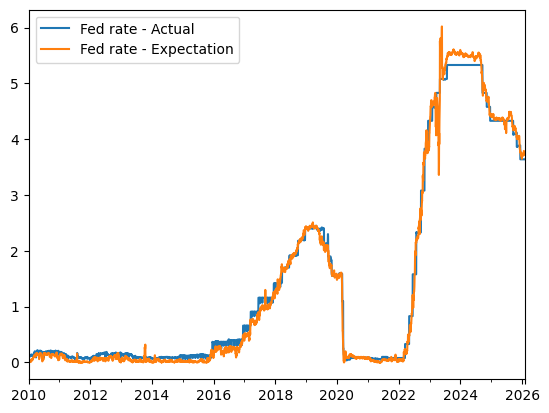

In [3]:
FRED_API_KEY = userdata.get('MY_FRED')
fred = Fred(api_key=FRED_API_KEY)
start_date = '2010-01-01'
end_date = '2026-02-01'
macro_tickers = {
    'Fed rate - Actual': 'DFF',
    'Fed rate - Expectation': 'DGS1MO'
}

macro_frames = []
for name, tid in macro_tickers.items():
    s = fred.get_series(tid, observation_start=start_date, observation_end=end_date)
    macro_frames.append(pd.DataFrame(s, columns=[name]))

macro_df = pd.concat(macro_frames, axis=1)
macro_df = macro_df.resample('B').ffill()
macro_df = macro_df.ffill()

plt.figure()
macro_df[['Fed rate - Actual','Fed rate - Expectation']].plot()
plt.show()

FOMC meegintek dátumai

forrás az ülések dátumaihoz: https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm#42827


In [4]:
fomc_dates_list = [
    # 2010
    '2010-01-27', '2010-03-16', '2010-04-28', '2010-06-23', '2010-08-10', '2010-09-21', '2010-11-03', '2010-12-14',
    # 2011
    '2011-01-26', '2011-03-15', '2011-04-27', '2011-06-22', '2011-08-09', '2011-09-21', '2011-11-02', '2011-12-13',
    # 2012
    '2012-01-25', '2012-03-13', '2012-04-25', '2012-06-20', '2012-08-01', '2012-09-13', '2012-10-24', '2012-12-12',
    # 2013
    '2013-01-30', '2013-03-20', '2013-05-01', '2013-06-19', '2013-07-31', '2013-09-18', '2013-10-30', '2013-12-18',
    # 2014
    '2014-01-29', '2014-03-19', '2014-04-30', '2014-06-18', '2014-07-30', '2014-09-17', '2014-10-29', '2014-12-17',
    # 2015
    '2015-01-28', '2015-03-18', '2015-04-29', '2015-06-17', '2015-07-29', '2015-09-17', '2015-10-28', '2015-12-16',
    # 2016
    '2016-01-27', '2016-03-16', '2016-04-27', '2016-06-15', '2016-07-27', '2016-09-21', '2016-11-02', '2016-12-14',
    # 2017
    '2017-02-01', '2017-03-15', '2017-05-03', '2017-06-14', '2017-07-26', '2017-09-20', '2017-11-01', '2017-12-13',
    # 2018
    '2018-01-31', '2018-03-21', '2018-05-02', '2018-06-13', '2018-07-31', '2018-09-26', '2018-11-08', '2018-12-19',
    # 2019
    '2019-01-30', '2019-03-20', '2019-05-01', '2019-06-19', '2019-07-31', '2019-09-18', '2019-10-30', '2019-12-11',
    # 2020 (Rendkívüli ülésekkel a COVID miatt)
    '2020-01-29', '2020-03-03', '2020-03-15', '2020-04-29', '2020-06-10', '2020-07-29', '2020-09-16', '2020-11-05', '2020-12-16',
    # 2021
    '2021-01-27', '2021-03-17', '2021-04-28', '2021-06-16', '2021-07-28', '2021-09-22', '2021-11-03', '2021-12-15',
    # 2022
    '2022-01-26', '2022-03-16', '2022-05-04', '2022-06-15', '2022-07-27', '2022-09-21', '2022-11-02', '2022-12-14',
    # 2023
    '2023-02-01', '2023-03-22', '2023-05-03', '2023-06-14', '2023-07-26', '2023-09-20', '2023-11-01', '2023-12-13',
    # 2024
    '2024-01-31', '2024-03-20', '2024-05-01', '2024-06-12', '2024-07-31', '2024-09-18', '2024-11-07', '2024-12-18',
    # 2025
    '2025-01-29', '2025-03-19', '2025-05-07', '2025-06-18', '2025-07-30', '2025-09-17', '2025-10-29', '2025-12-10',
    # 2026 (Februárig)
    '2026-01-28'
]

fomc_dates = pd.to_datetime(fomc_dates_list).sort_values()
display (fomc_dates)

df = pd.DataFrame(fomc_dates)
df.to_csv('FOMC_ulesek.csv')

DatetimeIndex(['2010-01-27', '2010-03-16', '2010-04-28', '2010-06-23',
               '2010-08-10', '2010-09-21', '2010-11-03', '2010-12-14',
               '2011-01-26', '2011-03-15',
               ...
               '2024-12-18', '2025-01-29', '2025-03-19', '2025-05-07',
               '2025-06-18', '2025-07-30', '2025-09-17', '2025-10-29',
               '2025-12-10', '2026-01-28'],
              dtype='datetime64[ns]', length=130, freq=None)

# Variancia

A monetáris politikai nézetek bizonytalanságát (Omega) egy dinamikus, horizont-alapú RMSE (Root Mean Square Error) becsléssel határoztam meg, összhangban az inflációs nowcast során alkalmazott módszertannal. A modell kizárólag a már lezárult FOMC ülések ténylegesen realizált előrejelzési hibáiból tanul, figyelembe véve az ülésig hátralévő kereskedési napok számát.

In [5]:
def calculate_fed_uncertainty(df, fomc_list, window_years, days):
    df_res = df.copy()

    # Következő ülés dátuma, az addig hátralévő munkanapok száma (days_left)
    df_res = df_res.asfreq('B').dropna(subset=['Fed rate - Expectation'])
    fomc = pd.to_datetime(fomc_list).sort_values()

    def get_next_info(d):
      future = fomc[fomc >= d]
      if not future.empty:
            next_m = future[0]
            # Munkanapok száma ma és az ülés között
            bd_left = np.busday_count(d.date(), next_m.date())
            return next_m, bd_left
      return np.nan, np.nan

    res_dates = df_res.index.map(get_next_info)
    df_res['next_fomc'] = [x[0] for x in res_dates]
    df_res['days_left'] = [x[1] for x in res_dates]

    # Következő meetingen meghatározott fed rate érétke
    actuals_shifted = df_res['Fed rate - Actual'].shift(-1) #mivel este 20:00-kor jön ki az új fed rate a piac csak másnap reagál
    actuals = actuals_shifted.loc[df_res.index.isin(fomc)]
    df_res['Actual_At_Meeting'] = df_res['next_fomc'].map(actuals)

    # RMSE minden napra: az aznap aktuális érték és a késöbbi tényleges fed rate négyzetes hibája
    df_res['SQ_Error_Fed'] = (df_res['Fed rate - Expectation'] - df_res['Actual_At_Meeting'])**2

    # RMSE számítása gördülő ablakkal (window_years)
    def get_fed_rmse(row, full_df):
        mask = (full_df['next_fomc'] < row.name) & \
               (full_df.index >= row.name - pd.DateOffset(years=window_years)) & \
               (full_df['days_left'].between(row['days_left'] - days, row['days_left'] + days))

        sq_errors = full_df.loc[mask, 'SQ_Error_Fed']
        return np.sqrt(sq_errors.mean()) if not sq_errors.empty else np.nan

    # Alkalmazás minden napra
    df_res['Fed_RMSE'] = df_res.apply(get_fed_rmse, axis=1, args=(df_res,))

    # Tisztítás és variancia
    df_res['Fed_RMSE'] = df_res['Fed_RMSE'].ffill().bfill()
    df_res['Fed_Var'] = df_res['Fed_RMSE']**2

    return df_res

macro_df = calculate_fed_uncertainty(macro_df, fomc_dates_list, 2, 2) #windowd_years, days
display (macro_df)

display(macro_df[['next_fomc', 'days_left', 'Fed rate - Expectation', 'Fed rate - Actual','Actual_At_Meeting', 'Fed_RMSE', 'Fed_Var']].tail(10))

,Fed rate - Actual,Fed rate - Expectation,next_fomc,days_left,Actual_At_Meeting,SQ_Error_Fed,Fed_RMSE,Fed_Var
2010-01-04,0.12,0.05,2010-01-27,17.0,0.12,0.0049,0.070000,0.004900
2010-01-05,0.12,0.03,2010-01-27,16.0,0.12,0.0081,0.070000,0.004900
2010-01-06,0.12,0.03,2010-01-27,15.0,0.12,0.0081,0.070000,0.004900
2010-01-07,0.10,0.02,2010-01-27,14.0,0.12,0.0100,0.070000,0.004900
2010-01-08,0.11,0.02,2010-01-27,13.0,0.12,0.0100,0.070000,0.004900
...,...,...,...,...,...,...,...,...
2026-01-26,3.64,3.77,2026-01-28,2.0,3.64,0.0169,0.152560,0.023275
2026-01-27,3.64,3.77,2026-01-28,1.0,3.64,0.0169,0.147234,0.021678
2026-01-28,3.64,3.76,2026-01-28,0.0,3.64,0.0144,0.142515,0.020310
2026-01-29,3.64,3.72,NaT,NaN,NaN,NaN,0.142515,0.020310


,next_fomc,days_left,Fed rate - Expectation,Fed rate - Actual,Actual_At_Meeting,Fed_RMSE,Fed_Var
2026-01-19,2026-01-28,7.0,3.75,3.64,3.64,0.208327,0.043400
2026-01-20,2026-01-28,6.0,3.75,3.64,3.64,0.194991,0.038022
2026-01-21,2026-01-28,5.0,3.75,3.64,3.64,0.182404,0.033271
2026-01-22,2026-01-28,4.0,3.79,3.64,3.64,0.171063,0.029262
2026-01-23,2026-01-28,3.0,3.78,3.64,3.64,0.162231,0.026319
2026-01-26,2026-01-28,2.0,3.77,3.64,3.64,0.152560,0.023275
2026-01-27,2026-01-28,1.0,3.77,3.64,3.64,0.147234,0.021678
2026-01-28,2026-01-28,0.0,3.76,3.64,3.64,0.142515,0.020310
2026-01-29,NaT,NaN,3.72,3.64,NaN,0.142515,0.020310
2026-01-30,NaT,NaN,3.72,3.64,NaN,0.142515,0.020310


Hátralévő napok száma (days_left) robosztus-e?

Horizontok eloszlása az adatsorban:


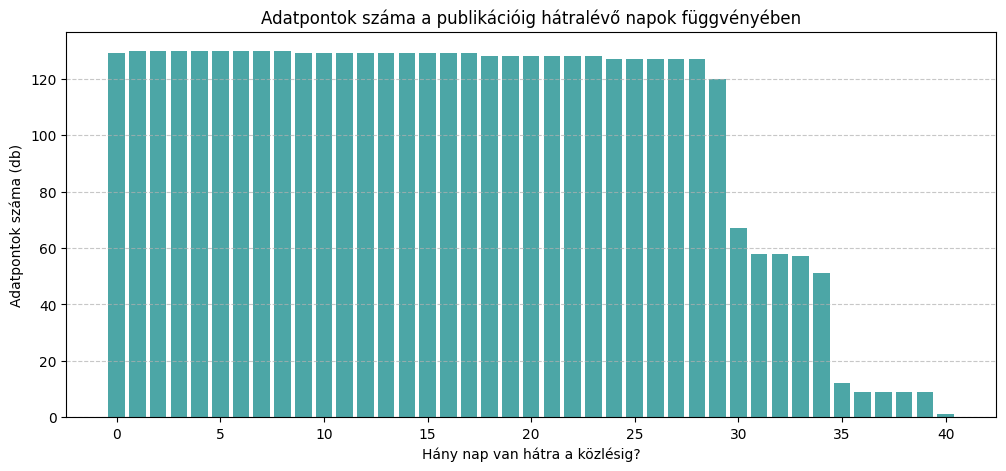

In [6]:
# Hány nap van hátra közlésig?
horizon_counts = macro_df['days_left'].value_counts().sort_index()
df_counts = horizon_counts.reset_index()
df_counts.columns = ['Napok a közlésig', 'Gyakoriság (db)']

print("Horizontok eloszlása az adatsorban:")
plt.figure(figsize=(12, 5))
plt.bar(df_counts['Napok a közlésig'], df_counts['Gyakoriság (db)'], color='teal', alpha=0.7)
plt.title('Adatpontok száma a publikációig hátralévő napok függvényében')
plt.xlabel('Hány nap van hátra a közlésig?')
plt.ylabel('Adatpontok száma (db)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

RMSE és variancia ábra

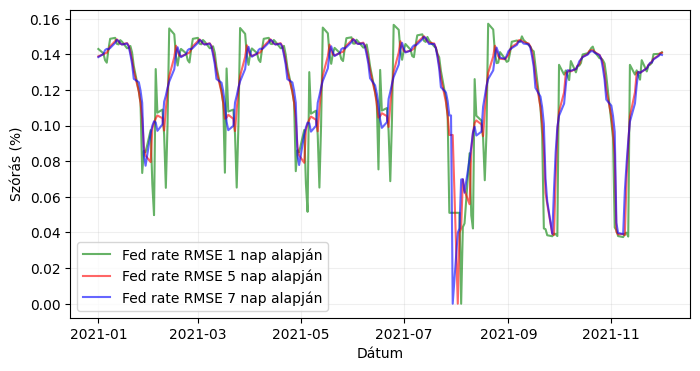

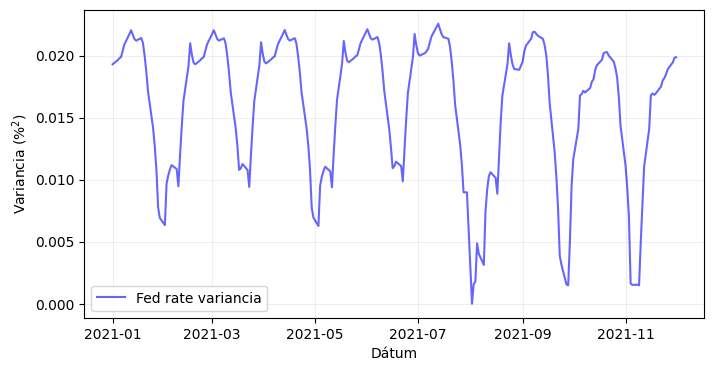

In [7]:
macro_df = calculate_fed_uncertainty(macro_df, fomc_dates_list, 2, 2) #végső választás: 2 nap, 2 év
macro_df2 = calculate_fed_uncertainty(macro_df, fomc_dates_list, 2, 0)
macro_df3 = calculate_fed_uncertainty(macro_df, fomc_dates_list, 2, 3)
df_zoom = macro_df.loc['2021-01-01':'2021-12-01']
df_zoom2 = macro_df2.loc['2021-01-01':'2021-12-01']
df_zoom3 = macro_df3.loc['2021-01-01':'2021-12-01']

# RMSE vizsgált intervallum mérete alapján
plt.figure(figsize=(8, 4))
plt.plot(df_zoom2['Fed_RMSE'], label='Fed rate RMSE 1 nap alapján', color='green', alpha=0.6)
plt.plot(df_zoom['Fed_RMSE'], label='Fed rate RMSE 5 nap alapján', color='red', alpha=0.6)
plt.plot(df_zoom3['Fed_RMSE'], label='Fed rate RMSE 7 nap alapján', color='blue', alpha=0.6)
plt.grid(True, alpha=0.2)
plt.legend()
plt.xlabel('Dátum')
plt.ylabel('Szórás (%)')
plt.savefig('FRED_Fedrate_RMSE.pdf', bbox_inches='tight')
plt.show()

# Fed rate előrejelzés (DGS1MO) hiba variancia +-2 napos intervallum mellett
plt.figure(figsize=(8, 4))
plt.plot(df_zoom['Fed_Var'], label='Fed rate variancia', color='blue', alpha=0.6)
plt.grid(True, alpha=0.2)
plt.legend()
plt.xlabel('Dátum')
plt.ylabel(r'Variancia (%$^2$)')
plt.savefig('FRED_Fedrate_Var.pdf', bbox_inches='tight')
plt.show()

# Adatbázis mentése

In [8]:
df_Fedrate_data = macro_df[['Fed rate - Actual','Fed rate - Expectation','Fed_Var']]
df_Fedrate_data.index.name = 'Date'
display(df_Fedrate_data)

df_Fedrate_data.to_csv('df_Fedrate_data.csv', index=True)

,Fed rate - Actual,Fed rate - Expectation,Fed_Var
Date,,,
2010-01-04,0.12,0.05,0.004900
2010-01-05,0.12,0.03,0.004900
2010-01-06,0.12,0.03,0.004900
2010-01-07,0.10,0.02,0.004900
2010-01-08,0.11,0.02,0.004900
...,...,...,...
2026-01-26,3.64,3.77,0.023275
2026-01-27,3.64,3.77,0.021678
2026-01-28,3.64,3.76,0.020310
